## Foreground ratio

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from model_ranking.data_structures.data.data import TARGET_CONFIGS
from pytorch3dunet.datasets.utils import _loader_classes 
from pytorch3dunet.datasets.hdf5 import DataAccessShapeWrapper

import pandas as pd

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
print(os.environ.get("CUDA_VISIBLE_DEVICES"))

5


Idea:
plot the distribution of foreground ratio in the datasets to see how much data gets thrown away when only using patchen with x amount of foreground pixels.

Using functions to load data by using dataset class and dataloader class to load the data and then calculate the foreground ratio for each patch and plot the distribution.


In [3]:
def get_fg_ratio(dataset_name, base_dir):
    # target config for the dataset
    target_cfg = TARGET_CONFIGS[dataset_name]

    # dataloader config for the test phase
    loader_config = target_cfg.loader.create_config(
        output_dir= '/g/kreshuk/lage/model_checkpoints',
        data_base_path= base_dir,
        phase='val'
    )

    # initialize datasets 
    loaders_config = loader_config.model_dump()
    loaders_config['val']['transformer']['label'] = [
        {"name": "ToTensor", "expand_dims": True}
    ]
    dataset_class = _loader_classes(loaders_config.get('dataset', 'StandardHDF5Dataset'))
    datasets = dataset_class.create_datasets(loaders_config, phase='val')
    ds = datasets[0]
    
    # H5 data
    if hasattr(ds, 'label_slices') and ds.label_slices is not None:
        label_wrapper = DataAccessShapeWrapper(
            ds.file_path,
            ds.label_internal_path,
            ds.roi,
            ds.auto_padding,
        )
        # ignore_index values? Do I need to take care of these? 
        fg_ratios = []
        for label_idx in ds.label_slices:
            patch = label_wrapper[label_idx]
            fg_ratios.append(np.count_nonzero(patch)/patch.size)
        del label_wrapper

    # TIF data — masks already loaded in memory
    elif hasattr(ds, 'masks') and ds.masks is not None:
        fg_ratios = [
            np.count_nonzero(mask)/mask.size
            for mask in ds.masks
        ]

    else:
        raise ValueError(f'Cannot compute fg ratios for dataset type {type(ds)}')

    del ds
    del datasets
    return np.array(fg_ratios)

In [5]:
# create overview of datasets with mean fg ratio and percentage of patches with any foreground

mito_data = ['EPFL', 'Hmito', 'Rmito']
mito_base_dir = '/scratch/lage/data/mitochondria'

In [6]:
# mitochondria datasets ratio

mito_fg_ratios = {}
for ds_name in mito_data:
    print(f"Calculating foreground ratios for {ds_name}...")
    mito_fg_ratios[ds_name] = get_fg_ratio(ds_name, mito_base_dir)

Calculating foreground ratios for EPFL...
2026-04-28 10:53:03,217 [MainThread] INFO HDF5Dataset - Loading val set from: /scratch/lage/data/mitochondria/EPFL/test.h5...
2026-04-28 10:53:03,222 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 256, 256) and volume_shape: (125, 480, 640)
2026-04-28 10:53:03,222 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.55991530418396, global std: 0.11937472969293594
2026-04-28 10:53:03,520 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2026-04-28 10:53:03,585 [MainThread] INFO HDF5Dataset - Number of patches: 750
Calculating foreground ratios for Hmito...
2026-04-28 10:53:03,646 [MainThread] INFO HDF5Dataset - Loading val set from: /scratch/lage/data/mitochondria/Hmito/test_converted.h5...
2026-04-28 10:53:03,650 [MainThread] INFO HDF5Dataset - Auto-calcul

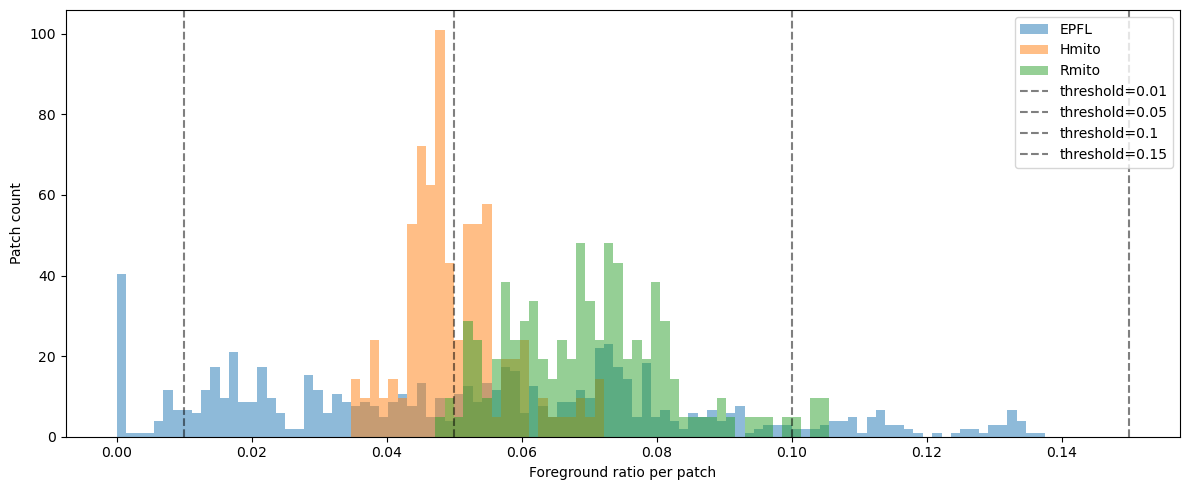

In [7]:
# Plotting mitochndria fg ratios

mito_combined = np.concatenate(list(mito_fg_ratios.values()))
bins = np.linspace(0, mito_combined.max(), 100)  # or np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(12, 5))

for dataset_name, ratios in mito_fg_ratios.items():
    ax.hist(ratios, bins= bins, alpha=0.5, label=dataset_name, density=True)

for t in [0.01, 0.05, 0.10, 0.15]:
    ax.axvline(t, linestyle='--', color='black', alpha=0.5, label=f'threshold={t}')

ax.set_xlabel('Foreground ratio per patch')
ax.set_ylabel('Patch count')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

In [8]:
# Table of mitochondria fg mito_fg

mito_rows = []

for mito_name, mito_fg in mito_fg_ratios.items():
    mean_fg = mito_fg.mean()
    percentage_any_fg = (mito_fg > 0).mean() *100
    # threshold so there is still enough data 
    nonzero = mito_fg[mito_fg > 0]
    possible_threshold = np.percentile(nonzero, 5) if len(nonzero) > 0 else 0.0
    patches_kept = (mito_fg > possible_threshold).mean() * 100
    
    mito_rows.append({
        'Dataset': mito_name,
        'Mean FG ratio': round(mean_fg, 3),
        'Patches with any FG (%)': round(percentage_any_fg, 1),
        'Suggested threshold': round(possible_threshold, 3),
        'Patches kept at threshold (%)': round(patches_kept, 1),
    })

df = pd.DataFrame(mito_rows)
df

,Dataset,Mean FG ratio,Patches with any FG (%),Suggested threshold,Patches kept at threshold (%)
0,EPFL,0.053,94.9,0.011,90.1
1,Hmito,0.050,100.0,0.038,94.7
2,Rmito,0.070,100.0,0.053,94.7


In [10]:
# nuclei datasets

nuclei_data = ['BBBC039', 'Go-Nuclear', 'HeLaNuc', 'Hoechst', 'S_BIAD895', 'S_BIAD1196']#'S_BIAD1410']

# 'S_BIAD1410' -> has no 'label_internal_path' but label_slices?? 
nuclei_base_dir = '/scratch/lage/data/nuclei'

# nuclei datasets ratio
nuclei_fg_ratios = {}
for ds_name in nuclei_data:
    print(f"Calculating foreground ratios for {ds_name}...")
    nuclei_fg_ratios[ds_name] = get_fg_ratio(ds_name, nuclei_base_dir)

Calculating foreground ratios for BBBC039...
Calculating foreground ratios for Go-Nuclear...
2026-04-28 10:55:01,169 [MainThread] INFO HDF5Dataset - Loading val set from: /scratch/lage/data/nuclei/Go-Nuclear/3d_all_in_one/1170.h5...
2026-04-28 10:55:01,172 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 256, 256) and volume_shape: (1, 753, 1672)
2026-04-28 10:55:01,172 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 2671.1584699347213, global std: 4768.746696570468
2026-04-28 10:55:05,532 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2026-04-28 10:55:05,870 [MainThread] INFO HDF5Dataset - Number of patches: 2520
Calculating foreground ratios for HeLaNuc...
Calculating foreground ratios for Hoechst...
Calculating foreground ratios for S_BIAD895...
Calculating foreground ratios for S_BIAD1196.

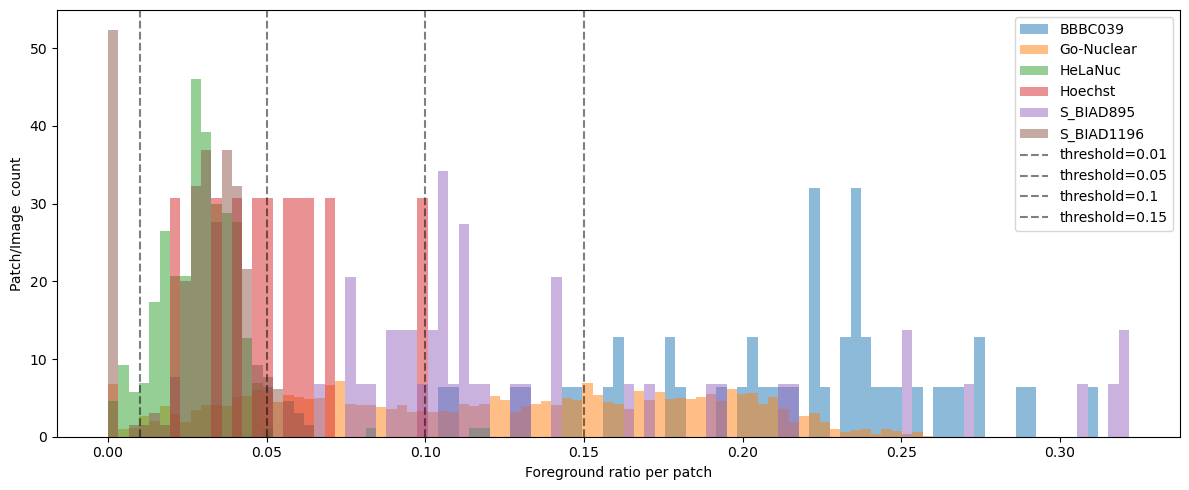

In [11]:
# Plotting nuclei foreground data distribution

nuc_combined = np.concatenate(list(nuclei_fg_ratios.values()))
bins = np.linspace(0, nuc_combined.max(), 100)  # or np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(12, 5))

for dataset_name, ratios in nuclei_fg_ratios.items():
    ax.hist(ratios, bins= bins, alpha=0.5, label=dataset_name, density=True)

for t in [0.01, 0.05, 0.10, 0.15]:
    ax.axvline(t, linestyle='--', color='black', alpha=0.5, label=f'threshold={t}')

ax.set_xlabel('Foreground ratio per patch')
ax.set_ylabel('Patch/Image  count')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

In [21]:
for dataset_name, ratios in nuclei_fg_ratios.items():
    print(dataset_name)
    threshold_25pct = np.percentile(ratios, 25)
    threshold_50pct = np.percentile(ratios, 50)
    threshold_75pct = np.percentile(ratios, 75)
    threshold_90pct = np.percentile(ratios, 90)
    print(f'Keep {25}% of patches → threshold={np.round(threshold_25pct,2)}%')
    print(f'Keep {50}% of patches → threshold={np.round(threshold_50pct,2)}%')
    print(f'Keep {75}% of patches → threshold={np.round(threshold_75pct,2)}%')
    print(f'Keep {90}% of patches → threshold={np.round(threshold_90pct,2)}%')


BBBC039
Keep 25% of patches → threshold=0.18%
Keep 50% of patches → threshold=0.22%
Keep 75% of patches → threshold=0.24%
Keep 90% of patches → threshold=0.27%
Go-Nuclear
Keep 25% of patches → threshold=0.06%
Keep 50% of patches → threshold=0.12%
Keep 75% of patches → threshold=0.18%
Keep 90% of patches → threshold=0.2%
HeLaNuc
Keep 25% of patches → threshold=0.02%
Keep 50% of patches → threshold=0.03%
Keep 75% of patches → threshold=0.04%
Keep 90% of patches → threshold=0.04%
Hoechst
Keep 25% of patches → threshold=0.04%
Keep 50% of patches → threshold=0.05%
Keep 75% of patches → threshold=0.06%
Keep 90% of patches → threshold=0.07%
S_BIAD895
Keep 25% of patches → threshold=0.1%
Keep 50% of patches → threshold=0.11%
Keep 75% of patches → threshold=0.17%
Keep 90% of patches → threshold=0.26%
S_BIAD1196
Keep 25% of patches → threshold=0.02%
Keep 50% of patches → threshold=0.03%
Keep 75% of patches → threshold=0.04%
Keep 90% of patches → threshold=0.05%
